# nanochat — Group Relative Policy Optimization (GRPO)

This notebook implements **GRPO** (Group Relative Policy Optimization) on top of the SFT-trained nanochat model.

**Prerequisites:** Run `nanochat.ipynb` (pretraining) and `nanochat-sft.ipynb` (supervised fine-tuning) first to produce `nanochat_sft_checkpoint.pkl`.

**Goal:** Fine-tune the model on a task with a *verifiable reward*:
> "Write a story about a [animal] in exactly N sentences."
>
> Reward = 1 if the response has exactly N sentences, else 0.

**Key concepts introduced:**
- Policy vs. reference model (KL divergence penalty)
- Group sampling: G completions per prompt
- Group-relative advantage normalization
- Clipped surrogate objective (PPO-style)
- Why GRPO works without a value/critic network


In [1]:
import pickle
import re
import jax
import jax.numpy as jnp
import numpy as np
import optax
import matplotlib.pyplot as plt
from functools import partial

print("JAX devices:", jax.devices())

JAX devices: [CpuDevice(id=0)]


## 1. Model definitions

The architecture and tokenizer are identical to `nanochat.ipynb` and `nanochat-sft.ipynb`. We reproduce them here in compact form so the notebook is self-contained.

In [2]:
import math
from bpe import bpe_encode, bpe_decode

# ── Checkpoint I/O ─────────────────────────────────────────────────────────────
def save_checkpoint(params, cfg, vocab, merges, path):
    with open(path, 'wb') as f:
        pickle.dump({'params': jax.tree_util.tree_map(np.array, params),
                     'cfg': cfg, 'vocab': vocab, 'merges': merges}, f)

def load_checkpoint(path):
    with open(path, 'rb') as f:
        s = pickle.load(f)
    vocab = s['vocab']
    merges = [tuple(m) for m in s['merges']]
    return jax.tree_util.tree_map(jnp.array, s['params']), s['cfg'], vocab, merges

# ── Model architecture (matches nanochat / nanochat-sft param structure) ───────
def rms_norm(g, x, eps=1e-6):
    return g * x / jnp.sqrt(jnp.mean(x**2, axis=-1, keepdims=True) + eps)

def precompute_rope(seq_len, head_dim, base=10000.):
    i = jnp.arange(0, head_dim, 2)
    angles = jnp.outer(jnp.arange(seq_len), 1.0 / (base ** (i / head_dim)))
    angles = jnp.concatenate([angles, angles], axis=-1)
    return jnp.cos(angles), jnp.sin(angles)

make_rotary = precompute_rope  # alias used in section 2

def apply_rope(x, cos, sin):
    d = x.shape[-1] // 2
    return x * cos + jnp.concatenate([-x[..., d:], x[..., :d]], axis=-1) * sin

def attention_forward(p, x, cos, sin, mask):
    B, T, d = x.shape; hd = cos.shape[-1]; H = d // hd
    Q, K, V = x @ p['Wq'], x @ p['Wk'], x @ p['Wv']
    def sh(t): return t.reshape(B, T, H, hd).transpose(0, 2, 1, 3)
    Q, K, V = sh(Q), sh(K), sh(V)
    c, s = cos[None, None], sin[None, None]
    Q = apply_rope(Q, c, s) / (jnp.linalg.norm(Q, axis=-1, keepdims=True) + 1e-6)
    K = apply_rope(K, c, s) / (jnp.linalg.norm(K, axis=-1, keepdims=True) + 1e-6)
    w = jax.nn.softmax(Q @ K.transpose(0, 1, 3, 2) / math.sqrt(hd) + mask[None, None], axis=-1)
    return (w @ V).transpose(0, 2, 1, 3).reshape(B, T, d) @ p['Wo'], w

def mlp_forward(p, x):
    return jax.nn.relu(x @ p['W1']) ** 2 @ p['W2']

def forward(params, ids, cos, sin, mask):
    x = params['tok_emb']['W'][ids]
    for blk in params['blocks']:
        x = x + attention_forward(blk['attn'], rms_norm(blk['norm1']['g'], x), cos, sin, mask)[0]
        x = x + mlp_forward(blk['mlp'], rms_norm(blk['norm2']['g'], x))
    return rms_norm(params['norm_f']['g'], x) @ params['head']['W'].T

## 2. Load the SFT checkpoint

We start from the SFT-trained model (`nanochat_sft_checkpoint.pkl`), which already knows how to follow the `[INST]…[/INST]` chat format. GRPO will nudge it to satisfy the sentence-count constraint.

In [3]:
params, cfg, vocab, merges = load_checkpoint('nanochat_sft_checkpoint.pkl')
print("cfg:", cfg)
print("vocab_size:", len(vocab))

T = cfg['seq_len']
dh = cfg['d_model'] // cfg['n_heads']
cos_c, sin_c = make_rotary(T, dh)
mask_c = jnp.triu(jnp.full((T, T), float('-inf')), k=1)

# Keep a frozen copy of the reference (SFT) policy for KL penalty
ref_params = jax.tree_util.tree_map(jnp.array, params)

cfg: {'vocab_size': 512, 'd_model': 128, 'n_heads': 4, 'n_layers': 4, 'd_ff': 512, 'head_dim': 32, 'seq_len': 128}
vocab_size: 512


## 3. GRPO theory

### Why we need RL after SFT

SFT teaches *format* (follow the chat template) but cannot optimize for *correctness* on tasks where the reward is non-differentiable — e.g., "does the output have exactly 3 sentences?" or "is the code correct?"

### The GRPO algorithm (DeepSeek-R1)

For each prompt $x$, sample **G completions** $\{y_1, \ldots, y_G\}$ from the current policy $\pi_\theta$ and compute their rewards $\{r_1, \ldots, r_G\}$.

**Group-relative advantage:** normalize within the group so no critic network is needed:

$$\hat{A}_i = \frac{r_i - \text{mean}(r_{1:G})}{\text{std}(r_{1:G}) + \epsilon}$$

**Clipped surrogate loss** (PPO-style): for each response token at position $t$,

$$\rho_{i,t} = \frac{\pi_\theta(y_{i,t} \mid x, y_{i,<t})}{\pi_{\theta_\text{old}}(y_{i,t} \mid x, y_{i,<t})}$$

$$\mathcal{L}_\text{clip} = -\frac{1}{G} \sum_i \hat{A}_i \cdot \min\!\left(\rho_{i,t},\; \text{clip}(\rho_{i,t}, 1-\varepsilon, 1+\varepsilon)\right)$$

**KL penalty** keeps the policy close to the reference (SFT) model and prevents reward hacking:

$$\mathcal{L}_\text{KL} = \mathbb{E}_{t}\!\left[\log\frac{\pi_\theta(y_t)}{\pi_\text{ref}(y_t)}\right]$$

**Total loss:**

$$\mathcal{L}_\text{GRPO} = \mathcal{L}_\text{clip} + \beta \cdot \mathcal{L}_\text{KL}$$

### Key insight

Because advantages are **group-relative**, a response only has a positive advantage if it scores *above the group mean*. This is an unbiased signal even with a binary 0/1 reward — as long as some completions succeed and some fail.

```
Prompt x ──► sample G=4 completions ──► score each with reward fn
                                                  │
                                         normalize (group-relative)
                                                  │
                                        gradient step on policy
                                        (clipped PPO + KL penalty)
```

## 4. Task: sentence-count reward

The model is asked:

> `[INST] Write a story about a {animal} in exactly {N} sentences. [/INST]`

**Reward:** 1 if the response (everything after `[/INST]`) has exactly N sentences, else 0.

A *sentence* is any run of text ending in `.`, `!`, or `?`. We count using a simple regex — no LLM judge needed.

In [4]:
ANIMALS = ['cat', 'dog', 'rabbit', 'fox', 'bear', 'owl', 'deer', 'frog', 'lion', 'duck']
TARGET_SENTENCES = [2, 3]  # tasks we train on


def count_sentences(text):
    """Count sentences ending in . ! or ?"""
    return len(re.findall(r'[^.!?]*[.!?]', text.strip()))


def make_prompt(animal, n):
    return f"[INST] Write a story about a {animal} in exactly {n} sentences. [/INST]"


def compute_reward(response_text, n_target):
    """Binary reward: 1 if response has exactly n_target sentences."""
    return float(count_sentences(response_text) == n_target)


# Quick sanity check
sample = "Once upon a time there was a fox. The fox was very clever! He outsmarted everyone."
print(f"Sentence count: {count_sentences(sample)}")  # should be 3
print(f"Reward (target=3): {compute_reward(sample, 3)}")
print(f"Reward (target=2): {compute_reward(sample, 2)}")

Sentence count: 3
Reward (target=3): 1.0
Reward (target=2): 0.0


## 5. Group sampling

For each prompt we sample **G completions** from the policy. We do this token-by-token with temperature sampling, running G sequences in parallel.

In [5]:
def sample_group(params, prompt_ids, G, max_new_tokens, temperature, key):
    """
    Sample G completions for a single prompt.

    Returns:
        completions: list of G token-id lists (response tokens only)
        full_seqs:   list of G token-id lists (prompt + response, padded to same length)
    """
    prompt_len = len(prompt_ids)
    seqs = [list(prompt_ids) for _ in range(G)]
    done = [False] * G

    for _ in range(max_new_tokens):
        if all(done):
            break
        key, subkey = jax.random.split(key)
        keys = jax.random.split(subkey, G)
        for i in range(G):
            if done[i]:
                continue
            ids = seqs[i][-T:]
            idx = jnp.array(ids)[None, :]  # (1, t)
            t = idx.shape[1]
            logits = forward(params, idx, cos_c[:t], sin_c[:t], mask_c[:t, :t])
            logits = logits[0, -1] / temperature  # (V,)
            next_tok = jax.random.categorical(keys[i], logits).item()
            seqs[i].append(next_tok)
            if len(seqs[i]) - prompt_len >= max_new_tokens:
                done[i] = True

    completions = [s[prompt_len:] for s in seqs]
    return completions, seqs


g           = 4
max_new     = 80
temperature = 0.9

# Demo: sample G completions for one prompt
animal, n = 'fox', 3
prompt_text = make_prompt(animal, n)
prompt_ids = bpe_encode(prompt_text, vocab, merges)
print(f"Prompt ({len(prompt_ids)} tokens): {prompt_text!r}\n")

key = jax.random.key(37)
completions, _ = sample_group(params, prompt_ids, G=g, max_new_tokens=max_new,
                               temperature=temperature, key=key)
for i, comp in enumerate(completions):
    text = bpe_decode(comp, vocab)
    reward = compute_reward(text, n)
    print(f"  [{i}] reward={reward:.0f} | {text[:80]!r}")

Prompt (42 tokens): '[INST] Write a story about a fox in exactly 3 sentences. [/INST]'

  [0] reward=0 | 'The tab m and it did not storeplious. Ever the n said, "I helpful timeven you ne'
  [1] reward=0 | '"She shed very gryfully inistuts the olnese! \nSuddenly. She thought a walked but'
  [2] reward=0 | 'This he said, Tim need, happy that of be a bouloreve. He worried. Her went out a'
  [3] reward=1 | "The ed to go down, Tim core branctus eadne's d, hug.\nSara had sut, so it togethe"


## 6. GRPO loss

The loss function operates on a *batch* of (prompt, completions, rewards) tuples. We compute:

1. **Log-probs under current policy** for each response token
2. **Log-probs under old policy** (the policy that generated the samples — needed for importance ratio $\rho$)
3. **Log-probs under reference policy** (frozen SFT weights — needed for KL term)
4. **Group-relative advantages**
5. **Clipped surrogate + KL loss**

In [6]:
def seq_log_probs(params, input_ids):
    """
    Compute per-token log-probs for a batch of sequences.
    input_ids: (B, T)  — the full sequences (prompt + response)
    Returns: (B, T-1) log-prob of each token given the previous context
    """
    B, L = input_ids.shape
    logits = forward(params, input_ids, cos_c[:L], sin_c[:L], mask_c[:L, :L])  # (B, L, V)
    log_probs = jax.nn.log_softmax(logits[:, :-1], axis=-1)  # (B, L-1, V)
    targets = input_ids[:, 1:]  # (B, L-1)
    return log_probs[jnp.arange(B)[:, None], jnp.arange(L-1)[None, :], targets]  # (B, L-1)


def grpo_loss(params, ref_params, input_ids, old_log_probs, response_mask, rewards,
              clip_eps=0.2, beta=0.04):
    """
    GRPO loss for a group of G completions.

    Args:
        params:        current policy parameters (to differentiate)
        ref_params:    frozen SFT reference parameters
        input_ids:     (G, L) token ids (prompt + response, zero-padded)
        old_log_probs: (G, L-1) log-probs under the *sampling* policy (stop-gradient)
        response_mask: (G, L-1) 1 at response positions, 0 at prompt / padding positions
        rewards:       (G,) scalar reward for each completion
        clip_eps:      PPO clipping epsilon
        beta:          KL penalty coefficient

    Returns:
        scalar loss (lower is better — we minimize)
    """
    G = rewards.shape[0]

    # 1. Group-relative advantages
    mean_r = rewards.mean()
    std_r = rewards.std() + 1e-8
    advantages = (rewards - mean_r) / std_r  # (G,)

    # 2. Log-probs under current and reference policy
    cur_log_probs = seq_log_probs(params, input_ids)      # (G, L-1)
    ref_log_probs = jax.lax.stop_gradient(
        seq_log_probs(ref_params, input_ids))              # (G, L-1)

    # 3. Importance ratio
    ratio = jnp.exp(cur_log_probs - old_log_probs)        # (G, L-1)

    # 4. Clipped surrogate (per token, then masked average)
    adv = advantages[:, None]  # broadcast over token dim
    surrogate = jnp.minimum(ratio * adv,
                            jnp.clip(ratio, 1 - clip_eps, 1 + clip_eps) * adv)
    clip_loss = -(surrogate * response_mask).sum() / (response_mask.sum() + 1e-8)

    # 5. KL penalty (current vs reference, token-level)
    kl = (cur_log_probs - ref_log_probs) * response_mask  # (G, L-1)
    kl_loss = kl.sum() / (response_mask.sum() + 1e-8)

    return clip_loss + beta * kl_loss

## 7. Building a GRPO batch

Before computing gradients we need to collect the *rollout*: for each prompt, sample G completions, score them, and assemble the arrays needed by `grpo_loss`.

In [7]:
def make_grpo_batch(params, animal, n_target, G, max_new_tokens, temperature, key):
    """
    Collect a rollout for one (animal, n_target) prompt.

    Returns:
        input_ids:     jnp array (G, L)
        old_log_probs: jnp array (G, L-1)   stop-gradient
        response_mask: jnp array (G, L-1)
        rewards:       jnp array (G,)
    """
    prompt_text = make_prompt(animal, n_target)
    prompt_ids = bpe_encode(prompt_text, vocab, merges)
    prompt_len = len(prompt_ids)

    completions, full_seqs = sample_group(
        params, prompt_ids, G, max_new_tokens, temperature, key)

    rewards_list = []
    for comp in completions:
        text = bpe_decode(comp, vocab)
        rewards_list.append(compute_reward(text, n_target))

    # Pad all sequences to the same length
    max_len = max(len(s) for s in full_seqs)
    max_len = min(max_len, T)  # respect context window
    padded = np.zeros((G, max_len), dtype=np.int32)
    for i, s in enumerate(full_seqs):
        s = s[:max_len]
        padded[i, :len(s)] = s

    # Response mask: 1 at positions after the prompt (shifted by 1 for targets)
    resp_mask = np.zeros((G, max_len - 1), dtype=np.float32)
    for i, s in enumerate(full_seqs):
        start = min(prompt_len, max_len - 1)
        end = min(len(s), max_len) - 1
        if end > start:
            resp_mask[i, start:end] = 1.0

    input_ids = jnp.array(padded)
    response_mask = jnp.array(resp_mask)
    rewards = jnp.array(rewards_list)

    # Compute old log-probs (stop-gradient — these are the sampling policy's probs)
    old_lp = jax.lax.stop_gradient(seq_log_probs(params, input_ids))

    return input_ids, old_lp, response_mask, rewards

## 8. Training loop

We alternate between:
1. **Rollout phase** — sample G completions per prompt (no gradient)
2. **Update phase** — one gradient step on the GRPO loss

We cycle over random (animal, N) pairs so the model sees diverse prompts.

In [8]:
grpo_steps = 150
lr         = 1e-5
clip_eps   = 0.2
beta       = 0.04

optimizer = optax.adamw(lr, weight_decay=0.1)
opt_state = optimizer.init(params)

loss_and_grad = jax.value_and_grad(grpo_loss, allow_int=True)

history = {'step': [], 'loss': [], 'reward': []}
rng = jax.random.key(0)

for step in range(grpo_steps):
    rng, k1, k2 = jax.random.split(rng, 3)

    animal = ANIMALS[int(jax.random.randint(k1, (), 0, len(ANIMALS)))]
    n_target = TARGET_SENTENCES[int(jax.random.randint(k2, (), 0, len(TARGET_SENTENCES)))]

    rng, k3 = jax.random.split(rng)
    input_ids, old_lp, response_mask, rewards = make_grpo_batch(
        params, animal, n_target, g, max_new, temperature, k3)

    mean_reward = float(rewards.mean())

    if rewards.std() < 1e-6:
        history['step'].append(step)
        history['loss'].append(float('nan'))
        history['reward'].append(mean_reward)
        if step % 10 == 0:
            print(f"step {step:3d} | skip (uniform reward {mean_reward:.2f}) | animal={animal}, n={n_target}")
        continue

    loss_val, grads = loss_and_grad(
        params, ref_params, input_ids, old_lp, response_mask, rewards,
        clip_eps, beta)
    updates, opt_state = optimizer.update(grads, opt_state, params)
    params = optax.apply_updates(params, updates)

    history['step'].append(step)
    history['loss'].append(float(loss_val))
    history['reward'].append(mean_reward)

    if step % 10 == 0:
        print(f"step {step:3d} | loss={loss_val:.4f} | reward={mean_reward:.2f} | animal={animal}, n={n_target}")

step   0 | skip (uniform reward 0.00) | animal=rabbit, n=3
step  10 | skip (uniform reward 0.00) | animal=deer, n=2
step  20 | loss=0.0003 | reward=0.50 | animal=rabbit, n=2
step  30 | loss=0.0004 | reward=0.25 | animal=rabbit, n=3
step  40 | skip (uniform reward 0.00) | animal=frog, n=2
step  50 | skip (uniform reward 0.00) | animal=fox, n=2
step  60 | loss=0.0005 | reward=0.25 | animal=dog, n=3
step  70 | skip (uniform reward 0.00) | animal=duck, n=2
step  80 | loss=0.0010 | reward=0.50 | animal=duck, n=3
step  90 | loss=0.0018 | reward=0.25 | animal=deer, n=3
step 100 | loss=0.0023 | reward=0.75 | animal=dog, n=2
step 110 | loss=0.0018 | reward=0.25 | animal=frog, n=3
step 120 | loss=0.0031 | reward=0.75 | animal=deer, n=2
step 130 | loss=0.0041 | reward=0.25 | animal=bear, n=3
step 140 | loss=0.0022 | reward=0.75 | animal=duck, n=3


## 9. Training curves

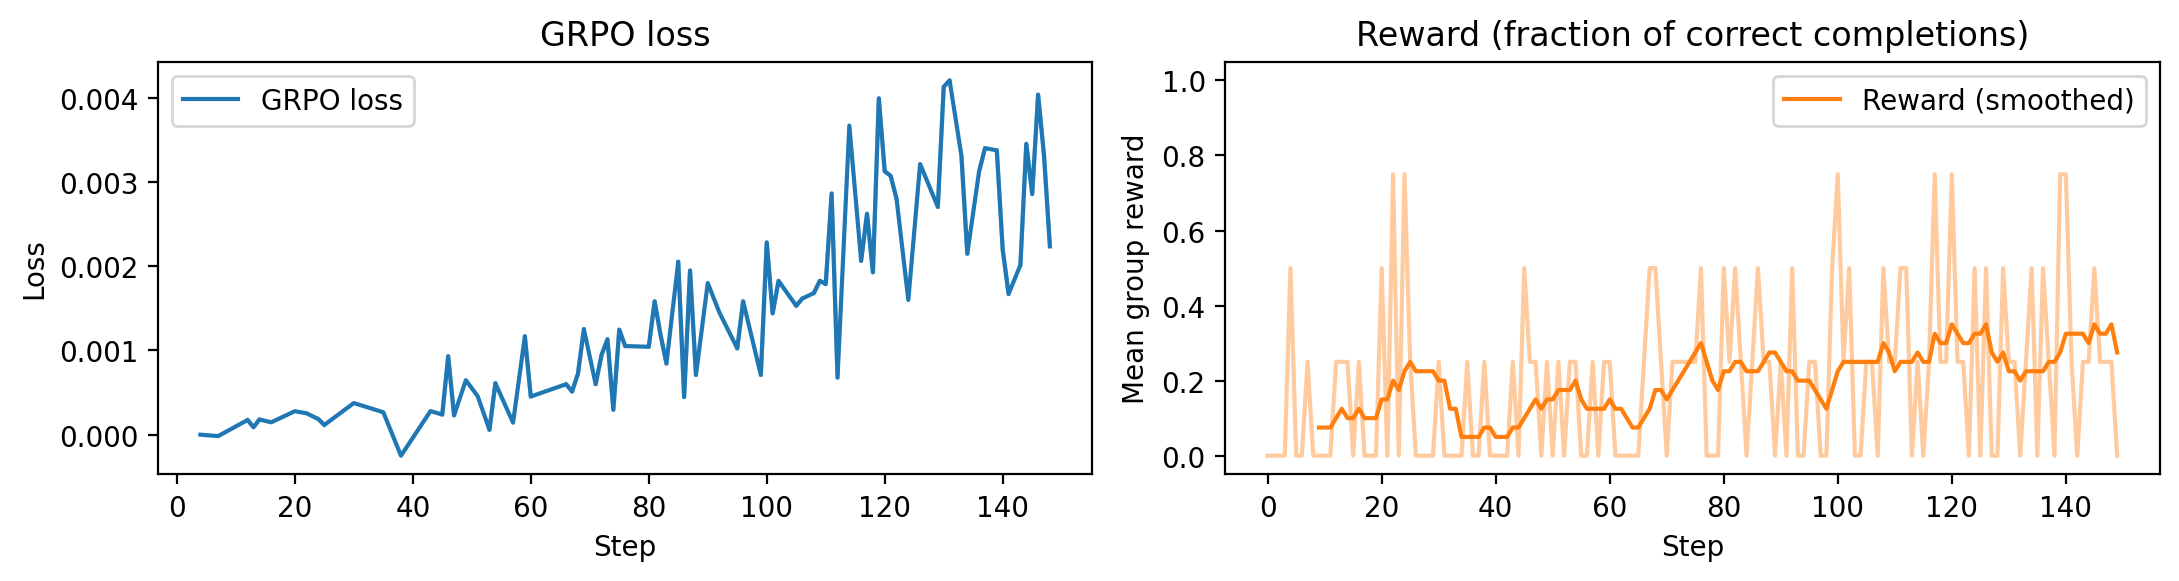

In [9]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 3))

steps = history['step']
losses = history['loss']
rewards = history['reward']

# Smooth rewards with a window
def smooth(xs, w=10):
    return np.convolve(xs, np.ones(w)/w, mode='valid')

ax1.plot(steps, losses, alpha=0.4, color='tab:blue')
valid = [(s, l) for s, l in zip(steps, losses) if not np.isnan(l)]
if valid:
    sv, lv = zip(*valid)
    ax1.plot(sv, lv, color='tab:blue', label='GRPO loss')
ax1.set_xlabel('Step'); ax1.set_ylabel('Loss'); ax1.set_title('GRPO loss')
ax1.legend()

ax2.plot(steps, rewards, alpha=0.4, color='tab:orange')
if len(rewards) >= 10:
    ax2.plot(steps[9:], smooth(rewards), color='tab:orange', label='Reward (smoothed)')
ax2.set_xlabel('Step'); ax2.set_ylabel('Mean group reward')
ax2.set_title('Reward (fraction of correct completions)')
ax2.set_ylim(-0.05, 1.05); ax2.legend()

plt.tight_layout()
plt.show()

### Why does the loss increase?

In supervised learning, loss going down means the model is improving. GRPO is different — **the reward is the metric to watch, not the loss**.

The GRPO loss is a clipped surrogate objective (like PPO), not a cross-entropy loss. Several things cause it to grow during training:

1. **Early steps produce no gradient.** When all G completions for a prompt receive the same reward, the group-relative advantage is zero and the step is skipped. As the model improves and rewards become more varied, actual gradient steps start happening — and the loss magnitude grows with them.

2. **The KL term accumulates.** The penalty `β · KL(current ‖ reference)` measures how far the policy has drifted from the frozen SFT checkpoint. A well-trained GRPO model *should* drift somewhat from SFT — that is the point — so this term rising is a sign of learning, not failure.

3. **Clipping creates asymmetry.** When the importance ratio is clipped (the policy has moved far from the sampling policy), the surrogate can increase even as the policy improves on the task.

**What to look at instead:** the reward curve. A rising mean reward — especially with fewer skipped steps — confirms the model is learning the sentence-count constraint.

## 10. Evaluation

Compare the SFT baseline vs the GRPO-trained model on held-out (animal, N) combinations.

In [10]:
def evaluate(params_dict, n_eval=20, G_eval=4, seed=7):
    """Estimate reward over n_eval random (animal, n) pairs."""
    rng = jax.random.key(seed)
    total_reward = 0.0
    count = 0
    for _ in range(n_eval):
        rng, k1, k2, k3 = jax.random.split(rng, 4)
        animal = ANIMALS[int(jax.random.randint(k1, (), 0, len(ANIMALS)))]
        n = TARGET_SENTENCES[int(jax.random.randint(k2, (), 0, len(TARGET_SENTENCES)))]
        prompt_ids = bpe_encode(make_prompt(animal, n), vocab, merges)
        comps, _ = sample_group(params_dict, prompt_ids, G_eval, max_new, 0.7, k3)
        for comp in comps:
            total_reward += compute_reward(bpe_decode(comp, vocab), n)
            count += 1
    return total_reward / count


sft_params, _, _, _ = load_checkpoint('nanochat_sft_checkpoint.pkl')

print("Evaluating SFT baseline …")
sft_score = evaluate(sft_params)
print(f"  SFT reward:  {sft_score:.3f}")

print("Evaluating GRPO model …")
grpo_score = evaluate(params)
print(f"  GRPO reward: {grpo_score:.3f}")

print(f"\nImprovement: {(grpo_score - sft_score):+.3f}")

Evaluating SFT baseline …
  SFT reward:  0.100
Evaluating GRPO model …
  GRPO reward: 0.338

Improvement: +0.238


## 11. Qualitative comparison

Inspect a few side-by-side generations from the SFT and GRPO models.

In [11]:
test_cases = [('rabbit', 2), ('owl', 3), ('bear', 2)]

for animal, n in test_cases:
    prompt_text = make_prompt(animal, n)
    prompt_ids = bpe_encode(prompt_text, vocab, merges)
    key = jax.random.key(99)

    sft_comps, _ = sample_group(sft_params, prompt_ids, 1, max_new, 0.7, key)
    grpo_comps, _ = sample_group(params,     prompt_ids, 1, max_new, 0.7, key)

    sft_text  = bpe_decode(sft_comps[0], vocab)
    grpo_text = bpe_decode(grpo_comps[0], vocab)

    print(f"\n{'='*60}")
    print(f"Prompt: {prompt_text}")
    print(f"\n  [SFT]  sentences={count_sentences(sft_text)}  reward={compute_reward(sft_text,n):.0f}")
    print(f"  {sft_text[:120]!r}")
    print(f"\n  [GRPO] sentences={count_sentences(grpo_text)}  reward={compute_reward(grpo_text,n):.0f}")
    print(f"  {grpo_text[:120]!r}")


Prompt: [INST] Write a story about a rabbit in exactly 2 sentences. [/INST]

  [SFT]  sentences=5  reward=0
  'One day, the perrange, there were very nack and he got the hnian the fam. They were airrel named Sallally, where were ma'

  [GRPO] sentences=2  reward=1
  'One day, the pisy was gifly angind and got the hne. \nShe was very how he was walking on the groud and her haveard and th'

Prompt: [INST] Write a story about a owl in exactly 3 sentences. [/INST]

  [SFT]  sentences=3  reward=1
  'One day, the perter was very happy sother cars, so he got the hne. \nShe was very how he was walking to make a big forey.'

  [GRPO] sentences=1  reward=0
  'One day, the perter was very happy cal of the story things. \nThe nimals were very nigue moudal of the storing suresss ar'

Prompt: [INST] Write a story about a bear in exactly 2 sentences. [/INST]

  [SFT]  sentences=5  reward=0
  'One day, the per, he could not sold and a vearagetter came to buil. \nOne and he was walking on the ground. 

## 12. Save GRPO checkpoint

In [12]:
save_checkpoint(params, cfg, vocab, merges, 'nanochat_grpo_checkpoint.pkl')
print("Saved nanochat_grpo_checkpoint.pkl")

Saved nanochat_grpo_checkpoint.pkl


## 13. Exercises

1. **More sentences.** Add `n=4` and `n=5` to `TARGET_SENTENCES`. Does the model generalize to sentence counts it was not trained on?

2. **Reward shaping.** Instead of a hard 0/1 reward, try a soft reward: `max(0, 1 - |count - n_target| / n_target)`. How does training stability change?

3. **Larger group.** Increase G from 4 to 8. How does this affect gradient variance and training speed?

4. **KL ablation.** Set `beta=0` (no KL penalty). Compare generation quality vs the default. What goes wrong?

5. **Different task.** Design a reward for "the story must contain the word *magic*". Implement `compute_reward` and train.

6. **Length penalty.** Add a secondary reward: subtract 0.1 for each token beyond 60. How does this interact with the sentence-count reward?

7. **Analysis.** Plot the per-step advantage distribution (mean and std of `rewards - rewards.mean()` across steps). What do you expect to see as training progresses?

## 14. Sketch: Reasoning Models

GRPO is the core algorithm behind **reasoning models** like DeepSeek-R1 and OpenAI o3. The key extension is simple: let the model think before answering.

### The idea

Introduce a thinking format:

```
<think>
... scratchpad tokens (invisible to reward) ...
</think>
<answer>... final answer ...</answer>
```

The reward function evaluates **only the `<answer>` part**, ignoring everything inside `<think>`. The model is free to write anything in the scratchpad — arithmetic steps, trial-and-error, re-reading the question — as long as the answer is correct.

No chain-of-thought supervision is needed. The model discovers reasoning as a strategy because it improves the reward signal.

### What changes in the training loop

1. **Tokenizer:** add special tokens `<think>`, `</think>`, `<answer>`, `</answer>`.
2. **Prompt format:** system prompt instructs the model to always think first.
3. **Rollout:** sample completions as before; parse out the answer span.
4. **Reward:** apply verifiable reward (correctness, format) to the answer span only.
5. **GRPO update:** unchanged — group-relative advantage, clipped surrogate loss, KL penalty.

Everything else — the model architecture, the optimizer, the group sampling — stays the same.

### What emerges

With enough model capacity and a task where reasoning helps (arithmetic, counting, logic), the model learns to:
- Use the scratchpad for intermediate computation
- Self-correct mid-generation
- Allocate more thinking tokens to harder problems

This is the "aha moment" described in the DeepSeek-R1 paper: the model spontaneously learns to reflect without being told to.

### Why it doesn't work at nanochat scale

Our 1M-parameter model is too small to exhibit emergent reasoning. Scratchpad use requires the model to (a) plan ahead and (b) condition reliably on its own prior tokens — both are capacity-limited. The DeepSeek-R1-Zero experiments start from a 7B base model. Still, the *mechanism* is identical to what we implemented here.

## References

- Shao et al. (2024). [DeepSeekMath: Pushing the Limits of Mathematical Reasoning in Open Language Models](https://arxiv.org/abs/2402.03300). *Introduces GRPO.*
- DeepSeek-AI (2025). [DeepSeek-R1: Incentivizing Reasoning Capability in LLMs via Reinforcement Learning](https://arxiv.org/abs/2501.12948). *Applies GRPO at scale; introduces the think-token format and documents emergent reasoning ("aha moment").*
- Schulman et al. (2017). [Proximal Policy Optimization Algorithms](https://arxiv.org/abs/1707.06347). *The PPO clipped surrogate objective.*
- Ouyang et al. (2022). [Training language models to follow instructions with human feedback](https://arxiv.org/abs/2203.02155). *InstructGPT / RLHF background.*
- Zeng et al. (2025). [SimpleRL-Zoo: Investigating and Taming the Dead Reward Problem in RL for LLMs](https://arxiv.org/abs/2503.18892). *Practical guide to reproducing R1-style reasoning RL training.*
- Karpathy (2025). [nanochat](https://github.com/karpathy/nanochat). *The pretrained model used as starting point.*